In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tifffile as tf
from glob import glob
import os

from scipy import ndimage, stats
from fastkde import fastKDE

In [2]:
struc1 = ndimage.generate_binary_structure(2,1)
struc2 = ndimage.generate_binary_structure(2,2)

wsrc = '../cell_dams/'
nsrc = '../nuclear_mask/'
csrc = '../data/'
dst = '../results/'

sample = 'B1'
pad = 15
pows2 = 2**np.arange(20) + 1

In [3]:
wall = tf.imread(wsrc + sample + '_dams.tif').astype(bool)
edt = tf.imread(nsrc + sample + '_EDT.tif')
nuclei = edt < 2
ncoords = np.array(np.nonzero(nuclei))
wcoords = np.array(np.nonzero(~wall))
imgcenter = np.array(wall.shape)//2

label, cellnum = ndimage.label(wall, struc1)
objss = ndimage.find_objects(label)
hist, bins = np.histogram(label, bins=range(1,cellnum+2))
#cnuclei = np.asarray(ndimage.center_of_mass(wall, label, range(1,cellnum+1)))
print('Detected',cellnum,'cells')

Detected 1662 cells


In [4]:
csizes = np.zeros((len(objss), 4))
for i in range(len(csizes)):
    csizes[i,0] = objss[i][0].stop - objss[i][0].start
    csizes[i,1] = objss[i][1].stop - objss[i][1].start
    csizes[i,2] = csizes[i,0]/csizes[i,1]
    csizes[i,3] = csizes[i,1]/csizes[i,0]
pd.DataFrame(csizes, columns=['X', 'Y', 'X/Y', 'Y/X']).describe()

,X,Y,X/Y,Y/X
count,1662.000000,1662.000000,1662.000000,1662.000000
mean,231.392298,203.286402,1.140593,0.957939
std,469.976162,355.388183,0.364748,0.294042
min,16.000000,21.000000,0.355556,0.183133
25%,71.000000,68.000000,0.905231,0.766141
50%,119.000000,109.000000,1.092611,0.915239
75%,252.750000,229.750000,1.305243,1.104691
max,15008.000000,10720.000000,5.460526,2.812500


In [5]:
transcriptomes = sorted([foo.split('/')[-2] for foo in glob(csrc + sample + '_data/*/')])
print(len(transcriptomes), 'transcriptomes')

filename = csrc + sample + '_data/32771-slide1_' + sample + '_results.txt'
data = pd.read_csv(filename, header=None, sep='\t').drop(columns=[4])
data.columns = ['X', 'Y', 'Z', 'T']

tsize = np.arange(len(transcriptomes))
for tidx in range(len(tsize)):
    tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
    tsize[tidx] = tcoords.shape[1]

targsort = np.argsort(tsize)[::-1]
for tidx in range(20):
    print(tidx+1, targsort[tidx], transcriptomes[targsort[tidx]], tsize[targsort[tidx]] , sep='\t')
    
print(data.shape)
# data.iloc[:,:3].describe().drop(index='count').T.astype(dict(zip(['min','25%','50%','75%','max'], [int for i in range(5)])))
data.head()

97 transcriptomes
1	26	GLYMA_05G092200	50577
2	57	GLYMA_11G008000	42563
3	28	GLYMA_05G216000	34377
4	32	GLYMA_06G168300	18417
5	72	GLYMA_15G169100	16513
6	43	GLYMA_08G125800	4259
7	10	CYP93A1	3023
8	62	GLYMA_12G027400	2463
9	12	GLYMA_01G019200	2317
10	19	GLYMA_03G029900	2261
11	90	GLYMA_18G197400	1843
12	53	GLYMA_10G070200	1815
13	50	GLYMA_09G216800	1726
14	84	GLYMA_17G185800	1607
15	25	GLYMA_05G023700	1537
16	70	GLYMA_15G008500	1105
17	79	GLYMA_16G165900	942
18	16	GLYMA_02G003700	914
19	41	GLYMA_08G011100	883
20	30	GLYMA_06G065000	825
(200807, 4)


,X,Y,Z,T
0,1788,532,16,BAC47856
1,1496,1715,18,BAC46169
2,777,1068,18,GLYMA_06G090100
3,1775,1389,18,GLYMA_06G090100
4,62,2103,20,GLYMA_06G090100


In [7]:
tidx = 57

tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
nmask = ~nuclei[ tcoords[1], tcoords[0] ]
print(np.sum(nmask), len(nmask) - np.sum(nmask), np.round(100*np.sum(nmask)/len(nmask),1), '%\n---', sep='\t')

tpercell = np.zeros((cellnum,2), dtype=int)
for i in range(cellnum):
    lmask = label[ tcoords[1], tcoords[0] ] == i + 1
    mask = lmask & nmask
    tpercell[i] = [ np.sum(lmask), np.sum(mask) ]

tpcargsort = np.argsort( tpercell[:,1] )[::-1]
for i in range(35):
    print(i, tpcargsort[i], tpercell[tpcargsort[i], 0], tpercell[tpcargsort[i], 1], sep='\t')

37066	5497	87.1	%
---
0	113	11885	8936
1	0	2433	2172
2	1567	409	379
3	1621	341	306
4	122	353	305
5	146	275	262
6	791	269	238
7	110	216	216
8	1562	166	166
9	140	160	160
10	155	174	159
11	2	171	157
12	1271	149	149
13	341	200	148
14	1623	147	147
15	1610	192	147
16	603	147	147
17	1527	168	142
18	162	141	141
19	1609	138	138
20	121	135	134
21	1260	133	133
22	1602	139	133
23	982	132	132
24	1568	130	130
25	710	130	129
26	1541	128	128
27	697	130	128
28	142	147	126
29	630	144	122
30	1617	153	121
31	576	119	119
32	1334	126	119
33	47	158	116
34	1576	131	114


In [8]:
cidx = 1567
cy, cx = csizes[cidx, :2].astype(int)
print(cy, cx, sep='\t')

xaxis = np.arange(0, cx+pad+1, pad)
yaxis = np.arange(0, cy+pad+1, pad)
print(len(xaxis), len(yaxis), sep='\t')

mx = np.nonzero(pows2 > 2*len(xaxis))[0][0]
my = np.nonzero(pows2 > 2*len(yaxis))[0][0]

print(mx,my, sep='\t')

foo = pows2[mx] - len(xaxis)
xneg = foo//2
if foo % 2 == 0:
    xpos = foo//2
else:
    xpos = foo//2 + 1
print(pows2[mx], foo, xneg, xpos, xneg + len(xaxis) + xpos, sep='\t')

foo = pows2[my] - len(yaxis)
yneg = foo//2
if foo % 2 == 0:
    ypos = foo//2
else:
    ypos = foo//2 + 1
    
print(pows2[my], foo, yneg, ypos, yneg + len(yaxis) + ypos, sep='\t')

xaxes = np.hstack((np.arange(-xneg, 0, 1)*pad, xaxis, np.arange(len(xaxis), len(xaxis)+xpos, 1)*pad))
yaxes = np.hstack((np.arange(-yneg, 0, 1)*pad, yaxis, np.arange(len(yaxis), len(yaxis)+ypos, 1)*pad))

print(len(xaxes) , len(yaxes), sep='\t')

1563	1370
93	106
8	8
257	164	82	82	257
257	151	75	76	257
257	257


In [9]:
ss = objss[cidx]
ss = ( np.s_[ ss[0].start: ss[0].start+yaxis[-1] ], np.s_[ ss[1].start: ss[1].start+xaxis[-1] ])
#ss = tuple([ np.s_[ np.max([0, ss[i].start - pad]) : np.min([ ss[i].stop + pad, wall.shape[i] ]) ] for i in range(len(ss)) ])

cell = wall[ss].copy().astype(np.uint8)
cell[ label[ss] == cidx+1 ] += 1

lmask = label[ tcoords[1], tcoords[0] ] == cidx + 1
mask = nmask & lmask

print(cell.shape, ss, np.sum(mask), sep='\t')

coords = tcoords[:, mask].copy()
coords[0] -= ss[1].start
coords[1] -= ss[0].start

wcellcoords = np.asarray(np.nonzero(~wall[ss]))

(1575, 1380)	(slice(10895, 12470, None), slice(6207, 7587, None))	379


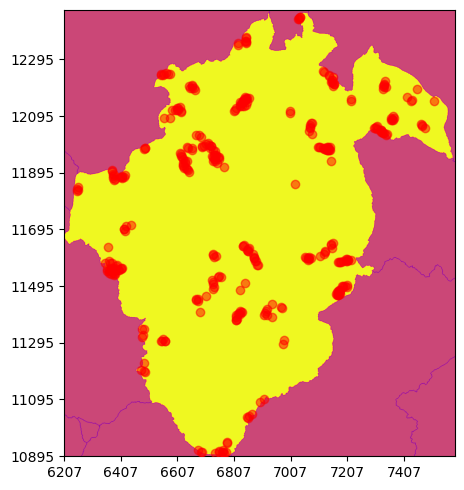

In [10]:
fig, ax = plt.subplots(1,1,figsize=(5,5), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

ax[0].imshow(cell, cmap='plasma', origin='lower')
ax[0].scatter(coords[0], coords[1], c='red', marker='o', zorder=3, alpha=0.5);

step = int(np.ediff1d(ax[0].get_xticks())[0])

ax[0].set_xticks(np.arange(0, cell.shape[1], step), np.arange(ss[1].start, ss[1].stop, step))
ax[0].set_yticks(np.arange(0, cell.shape[0], step), np.arange(ss[0].start, ss[0].stop, step))

fig.tight_layout();

In [11]:
bw = (4*pad**2)*len(coords[0])/hist[cidx]

In [12]:
fpdf0, vals0 = fastKDE.pdf(coords[0], coords[1], axes=[xaxes, yaxes], doApproximateECF=False, ecfPrecision=2 )
#fpdf0, vals0 = fastKDE.pdf(coords[0], coords[1])

print(fpdf0.shape, fpdf0.min(), fpdf0.max())

(257, 257) -7.570840115848023e-07 3.914923640904123e-06


In [13]:
#silverman = np.power( 4/(len(coords[0])*(cell.ndim + 2)) , 1/(cell.ndim + 4)) #* np.mean(np.std(coords[:cell.ndim], axis=1))
kde = stats.gaussian_kde(coords[:2], bw_method=bw)

X,Y = np.meshgrid(xaxis, yaxis)
pdf = kde.pdf(np.vstack((X.ravel(), Y.ravel())))

print(X.shape, np.min(pdf), np.max(pdf), sep='\t')

(106, 93)	2.5607729554997697e-19	1.9236940391312986e-06


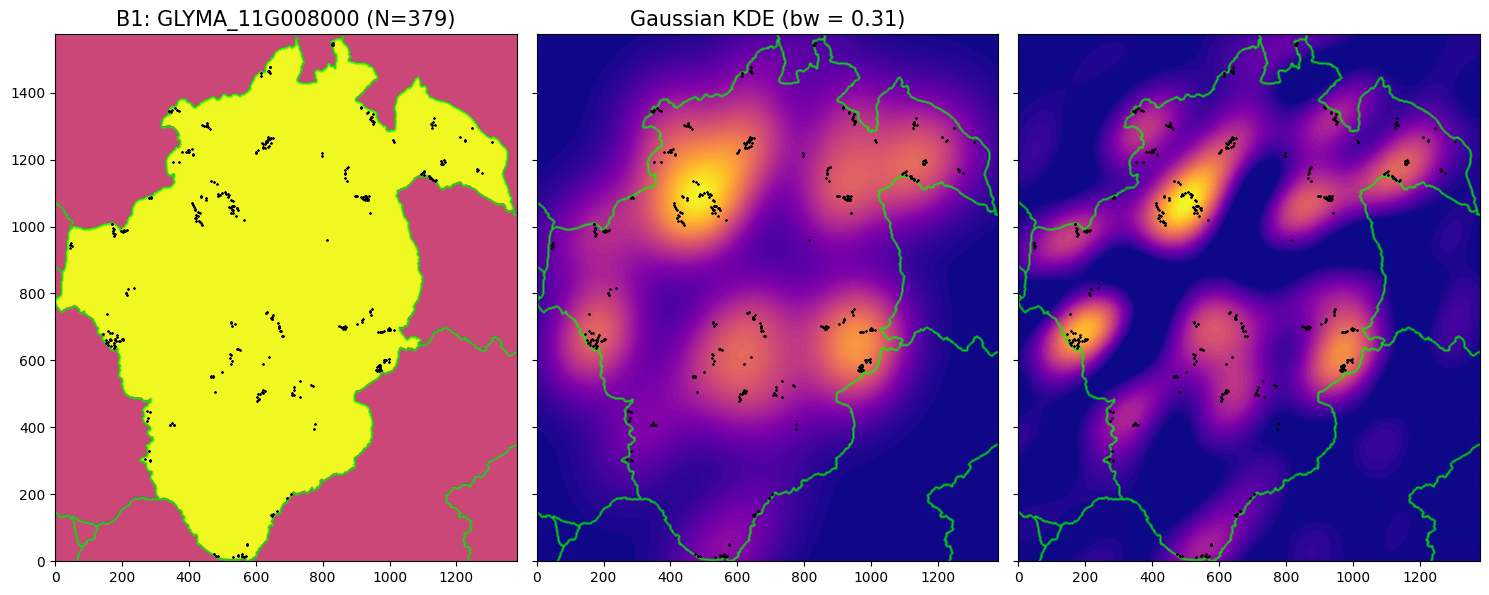

In [14]:
fs = 15
fig, ax = plt.subplots(1,3,figsize=(15,7), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

ax[0].imshow(cell, cmap='plasma', origin='lower')
cf = ax[1].contourf(X, Y, pdf.reshape(X.shape), 64, vmin=0, cmap='plasma')
ax[2].contourf(X,Y, fpdf0[yneg:-ypos, xneg:-xpos], 64, vmin=0, cmap='plasma')
#ax[2].contourf(vals0[0],vals0[1], fpdf0, 64, vmin=0, cmap='plasma')
#ax[3].contourf(vals1[0],vals1[1], fpdf1, 64, cmap='plasma')

step = int(np.ediff1d(ax[0].get_xticks())[0])

for i in range(len(ax)):
    ax[i].scatter(wcellcoords[1], wcellcoords[0], c='lime', marker='.', s=1, zorder=2, alpha=0.25);
    ax[i].set_aspect('equal')
    ax[i].scatter(coords[0], coords[1], c='k', marker='*', zorder=3, s=1);
    #ax[i].set_xticks(np.arange(0, cell.shape[1], step), np.arange(ss[1].start, ss[1].stop, step))
    #ax[i].set_yticks(np.arange(0, cell.shape[0], step), np.arange(ss[0].start, ss[0].stop, step))

ax[0].set_title('{}: {} (N={})'.format(sample, transcriptomes[tidx], len(coords[0])), fontsize=fs);
ax[1].set_title('Gaussian KDE (bw = {})'.format(np.round(kde.factor, 2)), fontsize=fs)
fig.tight_layout();

# Export `contourf`

[Path(array([[4.        , 1.625     ],
        [3.25      , 2.        ],
        [3.        , 2.16666667],
        [2.16666667, 3.        ],
        [2.        , 3.25      ],
        [1.625     , 4.        ]]), array([1, 2, 2, 2, 2, 2], dtype=uint8))]

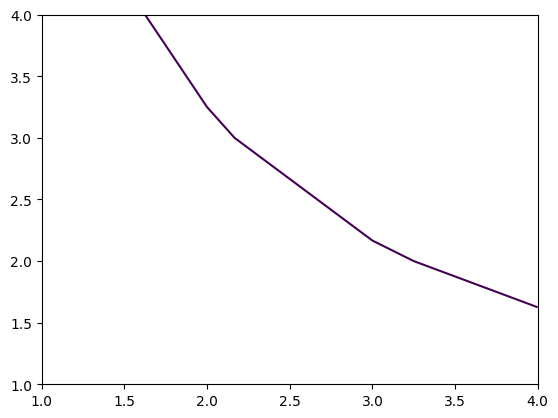

In [18]:
x = [1,2,3,4]
y = [1,2,3,4]
m = [[15,14,13,12],[14,12,10,8],[13,10,7,4],[12,8,4,0]]
cs = plt.contour(x,y,m, [9.5])
cs.collections[0].get_paths()

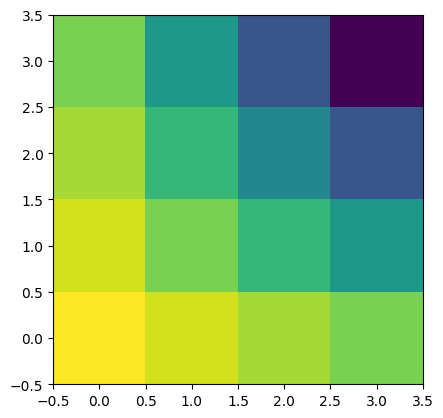

In [17]:
plt.imshow(m, origin='lower')